In [7]:
import numpy as np

In [35]:
import pandas as pd

In [36]:
import matplotlib.pyplot as plt

In [37]:
import seaborn as sns

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
from sklearn.linear_model import LogisticRegression

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
df = pd.read_csv(r"C:\Users\LaptopWala\Downloads\iris.csv")
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
df.shape

(150, 5)

In [15]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [16]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [18]:
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [19]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [20]:
 df.drop_duplicates()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [21]:
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [22]:
X = df.drop("species",axis = 1)
y = df["species"]

In [23]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size = 0.2, random_state= 42)

In [25]:
print(X_train.shape)

(120, 4)


In [26]:
print(X_test.shape)

(30, 4)


In [27]:
print(y_train.shape)

(120,)


In [28]:
print(y_test.shape)

(30,)


In [29]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(X_test)

In [31]:
X_test[:5]

array([[ 3.10997534e-01, -5.87763531e-01,  5.35295827e-01,
         1.75297293e-03],
       [-1.73673948e-01,  1.72626612e+00, -1.17067529e+00,
        -1.18150376e+00],
       [ 2.24968346e+00, -1.05056946e+00,  1.78634131e+00,
         1.44795564e+00],
       [ 1.89829664e-01, -3.56360566e-01,  4.21564419e-01,
         3.96171883e-01],
       [ 1.15917263e+00, -5.87763531e-01,  5.92161531e-01,
         2.64698913e-01]])

In [32]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy is: ", accuracy)

Accuracy is:  1.0


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


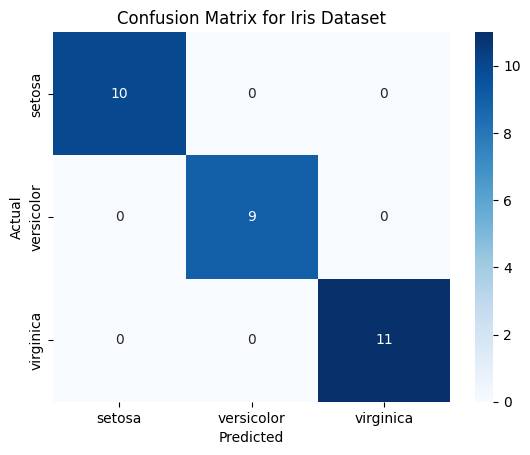


Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [41]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(
    cm,
    annot=True,        
    fmt='d',           
    cmap='Blues',      
    xticklabels=le.classes_, 
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Iris Dataset")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))